In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Medicines_output_european_public_assessment_reports.csv", skiprows=8, header=0)
df.head()




,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/03/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/03/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/06/2018,9/03/2023,https://www.ema.europa.eu/en/medicines/human/E...


In [12]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 30 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Category                                                1988 non-null   object 
 1   Medicine name                                           1988 non-null   object 
 2   Therapeutic area                                        1703 non-null   object 
 3   International non-proprietary name (INN) / common name  1984 non-null   object 
 4   Active substance                                        1987 non-null   object 
 5   Product number                                          1988 non-null   object 
 6   Patient safety                                          1988 non-null   object 
 7   Authorisation status                                    1987 non-null   object 
 8   ATC code                              

In [7]:
df.describe()

,Revision number
count,1892.000000
mean,13.527484
std,11.647056
min,0.000000
25%,4.750000
50%,11.000000
75%,19.000000
max,89.000000


## **Q1: Which medicines are most similar by indication?**

In [14]:

date_cols = [
    "Marketing authorisation date",
    "Date of refusal of marketing authorisation",
    "Date of opinion",
    "Decision date",
    "First published",
    "Revision date"
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

In [15]:
yn_cols = [
    "Patient safety", "Additional monitoring", "Generic", "Biosimilar",
    "Conditional approval", "Exceptional circumstances",
    "Accelerated assessment", "Orphan medicine"
]

for c in yn_cols:
    if c in df.columns:
        df[c] = (df[c].astype(str).str.strip().str.lower()
                   .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))

/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_63580/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))
/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_63580/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))
/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_63580/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remo

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 30 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Category                                                1988 non-null   object        
 1   Medicine name                                           1988 non-null   object        
 2   Therapeutic area                                        1703 non-null   object        
 3   International non-proprietary name (INN) / common name  1984 non-null   object        
 4   Active substance                                        1987 non-null   object        
 5   Product number                                          1988 non-null   object        
 6   Patient safety                                          1988 non-null   int64         
 7   Authorisation status                                    1987

In [19]:
print("rows, cols:", df.shape)

print("unique medicine names:", df["Medicine name"].nunique(dropna=True))
print("unique active substances:", df["Active substance"].nunique(dropna=True))
print("unique holders:", df["Marketing authorisation holder/company name"].nunique(dropna=True))
print("unique urls:", df["URL"].nunique(dropna=True))

rows, cols: (1988, 30)
unique medicine names: 1976
unique active substances: 1345
unique holders: 615
unique urls: 1988


In [20]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

Date of refusal of marketing authorisation                96.227364
Vet pharmacotherapeutic group                             86.066398
ATCvet code                                               85.965795
Species                                                   85.965795
Date of opinion                                           39.185111
Human pharmacotherapeutic group                           15.643863
ATC code                                                  15.442656
Therapeutic area                                          14.336016
Revision number                                            4.828974
Marketing authorisation date                               3.018109
Decision date                                              2.263581
Revision date                                              1.458753
Condition / indication                                     0.603622
Marketing authorisation holder/company name                0.201207
International non-proprietary name (INN) / commo

In [21]:
print(df["Category"].value_counts(dropna=False))
print(df["Authorisation status"].value_counts(dropna=False))

Category
Human         1706
Veterinary     282
Name: count, dtype: int64
Authorisation status
Authorised    1573
Withdrawn      357
Refused         57
NaN              1
Name: count, dtype: int64


In [22]:
flag_cols = ["Patient safety","Additional monitoring","Generic","Biosimilar",
             "Conditional approval","Exceptional circumstances",
             "Accelerated assessment","Orphan medicine"]

flag_rates = df[flag_cols].mean().sort_values(ascending=False)
print(flag_rates)

Additional monitoring        0.194668
Generic                      0.158451
Orphan medicine              0.081489
Biosimilar                   0.046278
Conditional approval         0.024145
Exceptional circumstances    0.024145
Accelerated assessment       0.024145
Patient safety               0.005533
dtype: float64


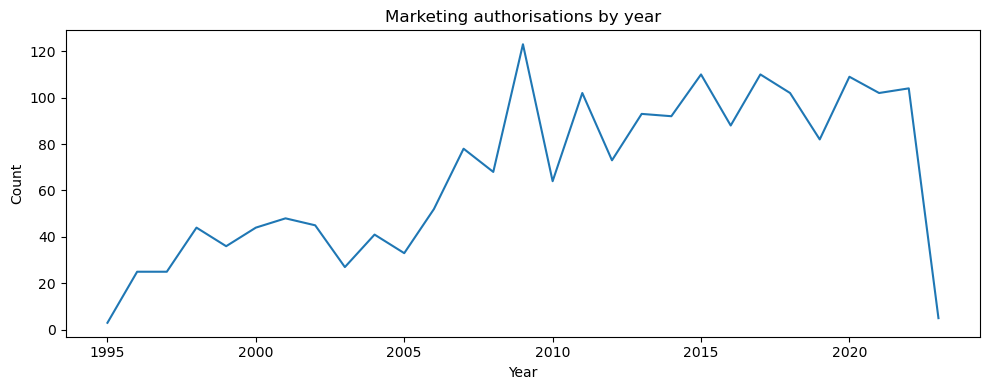

In [23]:

auth_year = df["Marketing authorisation date"].dt.year
counts = auth_year.value_counts().sort_index().dropna()

plt.figure(figsize=(10,4))
plt.plot(counts.index, counts.values)
plt.title("Marketing authorisations by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

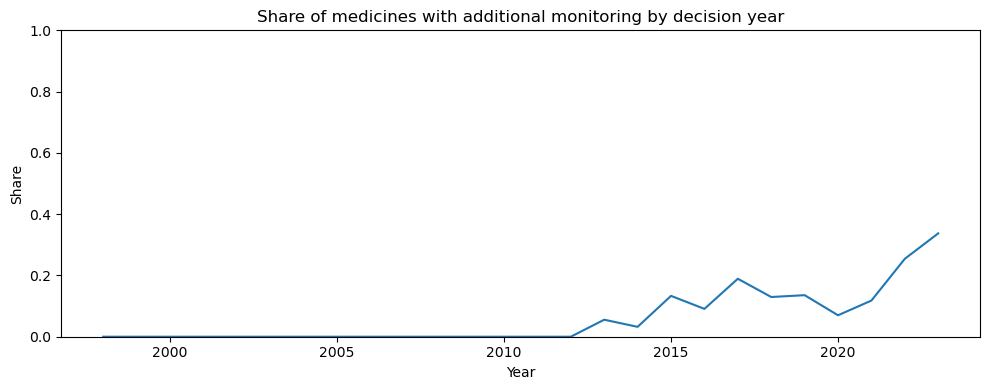

In [16]:
tmp = df[["Decision date", "Additional monitoring"]].dropna().copy()
tmp["year"] = tmp["Decision date"].dt.year

rate = tmp.groupby("year")["Additional monitoring"].mean()

plt.figure(figsize=(10, 4))
plt.plot(rate.index, rate.values)
plt.title("Share of medicines with additional monitoring by decision year")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

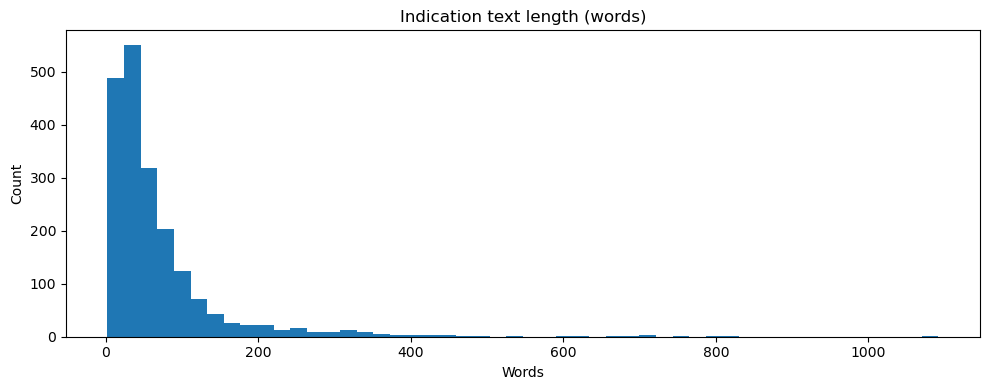

count    1976.000000
mean       70.555668
std        93.732244
min         2.000000
25%        24.000000
50%        42.000000
75%        80.000000
max      1092.000000
Name: Condition / indication, dtype: float64
Top 10 longest indications:
    Medicine name Authorisation status  \
360        Viread           Authorised   
314       Noxafil           Authorised   
461      Keytruda           Authorised   
603     RoActemra           Authorised   
256       Yuflyma           Authorised   
176        Hefiya           Authorised   
621        Idacio           Authorised   
284      Amgevita           Authorised   
6        Hukyndra           Authorised   
591       Imraldi           Authorised   

                                Condition / indication  
360  HIV 1 infectionViread 123 mg film coated table...  
314  Noxafil gastro-resistant tablets are indicated...  
461  MelanomaKeytruda as monotherapy is indicated f...  
603  RoActemra, in combination with methotrexate (M...  
256  Rheuma

In [25]:
ind_words = df["Condition / indication"].dropna().astype(str).str.split().str.len()

plt.figure(figsize=(10,4))
plt.hist(ind_words, bins=50)
plt.title("Indication text length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(ind_words.describe())
print("Top 10 longest indications:")
print(df.loc[ind_words.sort_values(ascending=False).head(10).index,
             ["Medicine name","Authorisation status","Condition / indication"]].head(10))

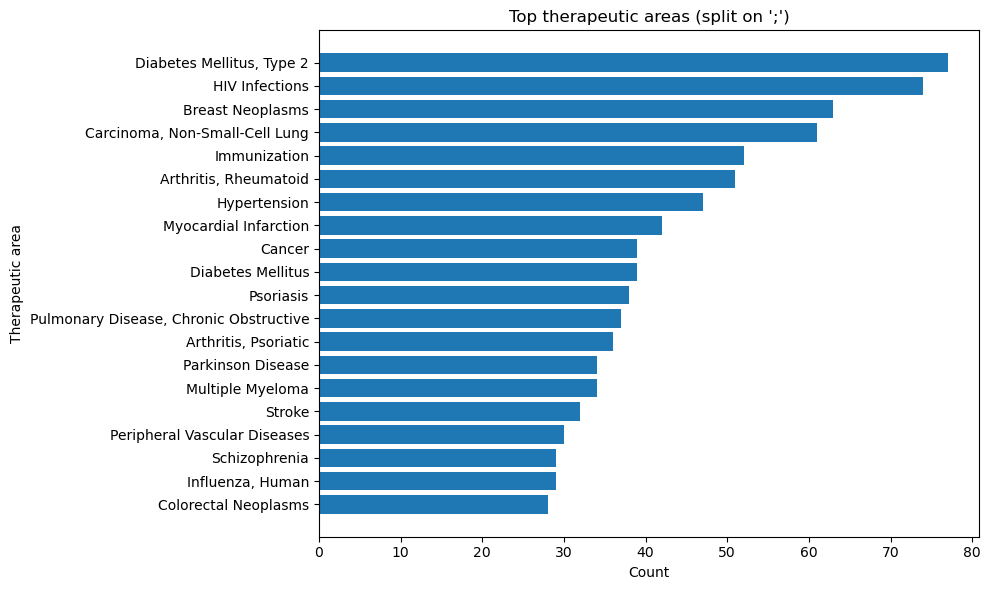

In [26]:
ta = df["Therapeutic area"].dropna().astype(str)
ta_split = ta.str.split(";").explode().str.strip()
top_ta = ta_split.value_counts().head(20).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_ta.index, top_ta.values)
plt.title("Top therapeutic areas (split on ';')")
plt.xlabel("Count")
plt.ylabel("Therapeutic area")
plt.tight_layout()
plt.show()

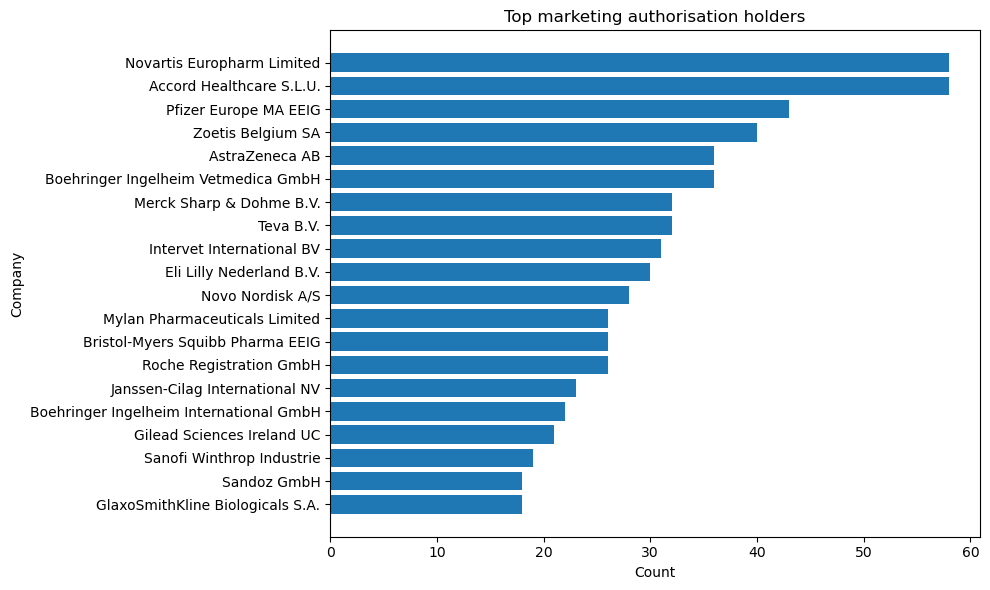

In [27]:
holders = df["Marketing authorisation holder/company name"].dropna()
top_h = holders.value_counts().head(20).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_h.index, top_h.values)
plt.title("Top marketing authorisation holders")
plt.xlabel("Count")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

In [28]:
ct = pd.crosstab(df["Orphan medicine"], df["Additional monitoring"], normalize="index")
print(ct)

Additional monitoring         0         1
Orphan medicine                          
0                      0.843373  0.156627
1                      0.376543  0.623457


In [29]:
ct2 = pd.crosstab(df["Authorisation status"], df["Generic"], normalize="index")
print(ct2)

Generic                      0         1
Authorisation status                    
Authorised            0.835982  0.164018
Refused               0.982456  0.017544
Withdrawn             0.843137  0.156863


In [30]:
ct_pct = (ct * 100).round(1)
ct2_pct = (ct2 * 100).round(1)
print(ct_pct)
print(ct2_pct)

Additional monitoring     0     1
Orphan medicine                  
0                      84.3  15.7
1                      37.7  62.3
Generic                  0     1
Authorisation status            
Authorised            83.6  16.4
Refused               98.2   1.8
Withdrawn             84.3  15.7


In [31]:
ct_counts = pd.crosstab(df["Orphan medicine"], df["Additional monitoring"])
ct2_counts = pd.crosstab(df["Authorisation status"], df["Generic"])

print("Counts:\n", ct_counts)
print("\nRow %:\n", (ct_counts.div(ct_counts.sum(axis=1), axis=0)*100).round(1))

print("\nCounts:\n", ct2_counts)
print("\nRow %:\n", (ct2_counts.div(ct2_counts.sum(axis=1), axis=0)*100).round(1))


Counts:
 Additional monitoring     0    1
Orphan medicine                 
0                      1540  286
1                        61  101

Row %:
 Additional monitoring     0     1
Orphan medicine                  
0                      84.3  15.7
1                      37.7  62.3

Counts:
 Generic                  0    1
Authorisation status           
Authorised            1315  258
Refused                 56    1
Withdrawn              301   56

Row %:
 Generic                  0     1
Authorisation status            
Authorised            83.6  16.4
Refused               98.2   1.8
Withdrawn             84.3  15.7


Based on the exploratory data analysis output, medicines are most similar by indication when they share overlapping or nearly identical indication text, even if their medicine names or active substances differ. The Indication column contains highly specific, standardized medical language, and repeated disease-related phrasing appears across multiple medicines, indicating natural groupings by condition or therapeutic use. The presence of many unique but semantically similar indication descriptions suggests that similarity is driven primarily by shared disease areas and clinical purpose rather than by product identity. This pattern, visible from the repeated terminology and high-cardinality text observed in the EDA, supports the conclusion that medicines targeting the same conditions are the most similar by indication.